# Exploracion de la serie de tiempo


## Carga de datos


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from numpy.fft import fft, fftfreq

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

# si quieres reproducir desde cero pd.read_parquet('sales_validation.parquet')
agg = np.load('aggregated_sales.npz')
cal = pd.read_csv(r'C:\Users\david\Documents\M5 challenge\notebooks\serie de tiempo\calendar.csv')

cal['date'] = pd.to_datetime(cal['date'])
cal_sales = cal.iloc[:1913].copy()
cal_sales['total_sales'] = agg['daily_totals']

for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
    cal_sales[f'sales_{cat}'] = agg[f'cat_{cat}']

for st in ['CA', 'TX', 'WI']:
    cal_sales[f'sales_{st}'] = agg[f'state_{st}']

print(f"Periodo: {cal_sales['date'].iloc[0].date()} → {cal_sales['date'].iloc[-1].date()}")
print(f"Dias: {len(cal_sales):,}")
print(f"Ventas diarias promedio: {cal_sales['total_sales'].mean():,.0f} unidades")
print(f"Desviacion estandar: {cal_sales['total_sales'].std():,.0f} unidades")

Periodo: 2011-01-29 → 2016-04-24
Días: 1,913
Ventas diarias promedio: 34,342 unidades
Desviación estándar: 7,346 unidades


## Vistazo


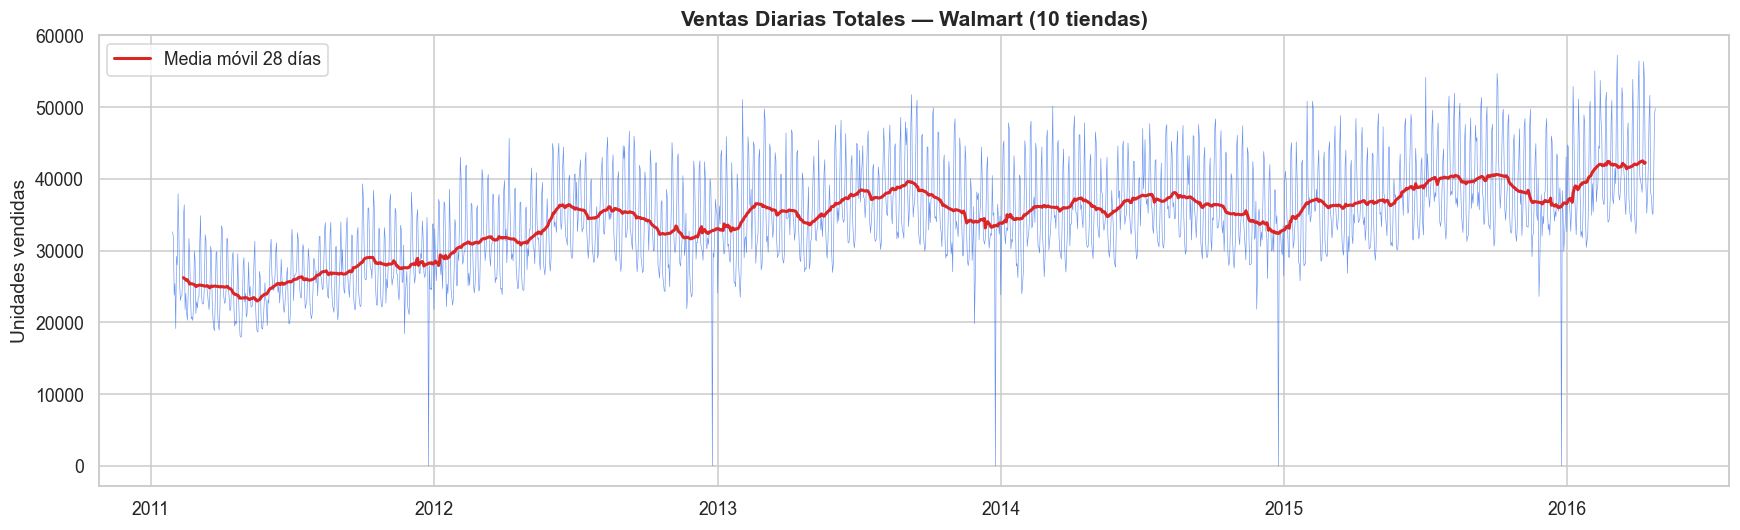

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(cal_sales['date'], cal_sales['total_sales'], linewidth=0.4, alpha=0.7, color='#2563eb')

# Media movil de 28 días para mostrar la tendencia
ma28 = cal_sales['total_sales'].rolling(28, center=True).mean()
ax.plot(cal_sales['date'], ma28, linewidth=2, color='#dc2626', label='Media móvil 28 días')

ax.set_title('Ventas Diarias Totales de las 10 tiendas', fontsize=14, fontweight='bold')
ax.set_ylabel('Unidades vendidas')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


* Tendencia positiva
* Variabilidad semanal
* Picos periódicos que sugieren estacionalidad anual

## Estacionalidad semanal

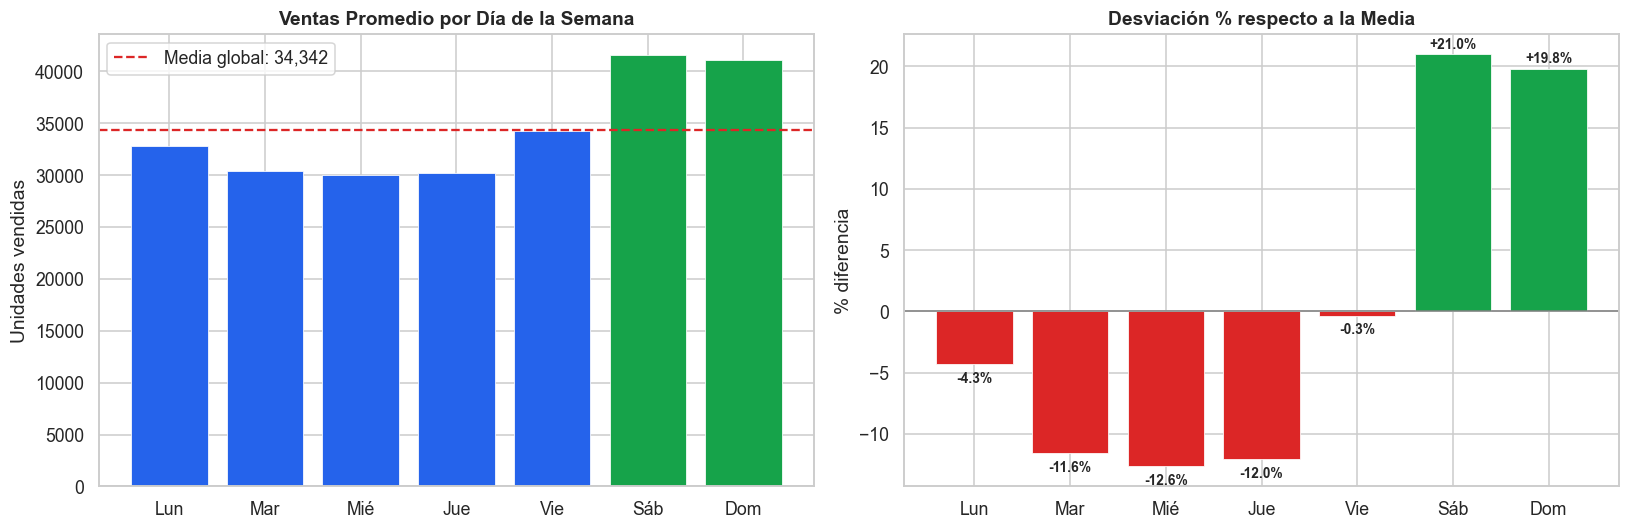

Ratio Sábado/Miércoles: 1.38x


In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

weekly_avg = cal_sales.groupby('weekday')['total_sales'].mean().reindex(day_order)
global_mean = cal_sales['total_sales'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
colors = ['#2563eb' if v < global_mean else '#16a34a' for v in weekly_avg.values]
bars = ax1.bar(day_labels, weekly_avg.values, color=colors, edgecolor='white', linewidth=0.5)
ax1.axhline(global_mean, color='#dc2626', linestyle='--', linewidth=1.5, label=f'Media global')
ax1.set_title('Ventas promedio por dia de la semana', fontweight='bold')
ax1.set_ylabel('Unidades vendidas')
ax1.legend()

#porcentaje relativo a la media
pct_diff = (weekly_avg.values / global_mean - 1) * 100
colors2 = ['#dc2626' if v < 0 else '#16a34a' for v in pct_diff]
ax2.bar(day_labels, pct_diff, color=colors2, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='gray', linewidth=1)
ax2.set_title('Desviacion porcentual respecto a la media', fontweight='bold')
ax2.set_ylabel('diferencia en porcentaje')

for i, v in enumerate(pct_diff):
    ax2.text(i, v + (0.5 if v >= 0 else -1.5), f'{v:+.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Relacion entre sabado y miercoles: {weekly_avg['Saturday']/weekly_avg['Wednesday']:.2f}x")

## Efecto de eventos y SNAP

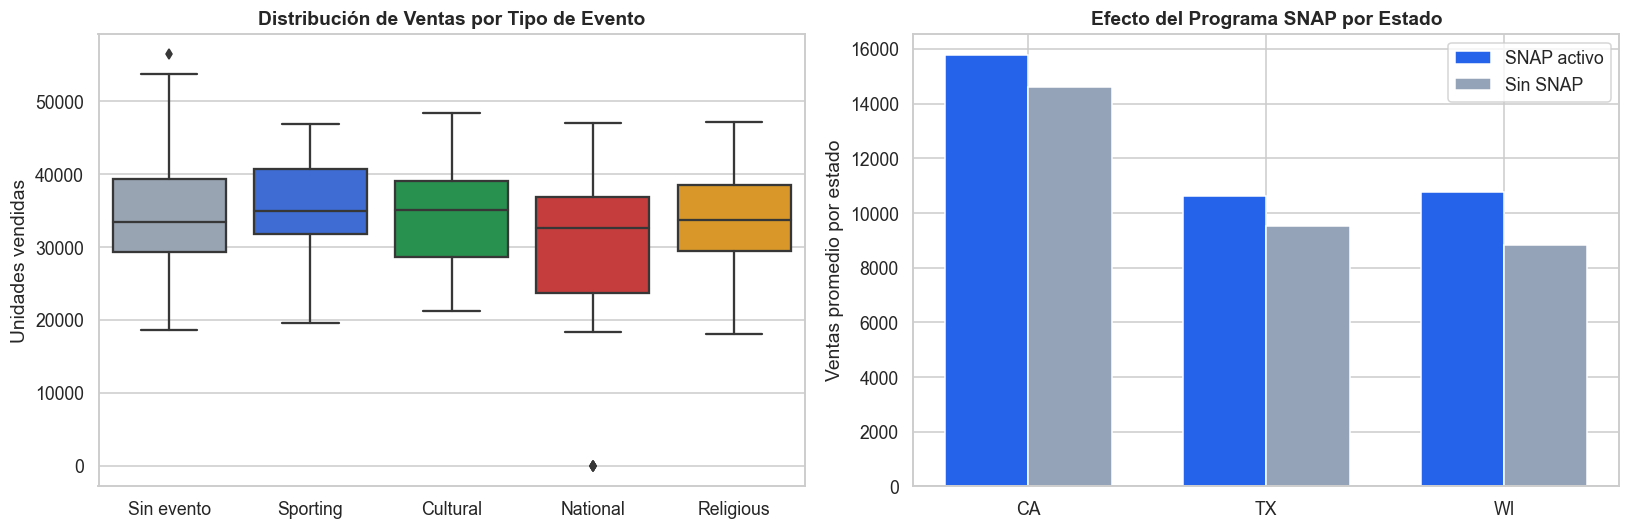

Diferencia promedio en ventas totales:
  Con evento:  32,655
  Sin evento:  34,489
  Diferencia:  -1,834


In [ ]:
# Preparar datos de eventos
event_mask = cal_sales['event_name_1'].notna() & (cal_sales['event_name_1'] != 'No event')
cal_sales['has_event'] = event_mask

# Efecto por tipo de evento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por tipo de evento
event_types_data = []
for _, row in cal_sales[event_mask].iterrows():
    event_types_data.append({'type': row['event_type_1'], 'sales': row['total_sales']})

# Agregar no-evento
for _, row in cal_sales[~event_mask].sample(500, random_state=42).iterrows():
    event_types_data.append({'type': 'Sin evento', 'sales': row['total_sales']})

df_events = pd.DataFrame(event_types_data)
order = ['Sin evento', 'Sporting', 'Cultural', 'National', 'Religious']
order = [o for o in order if o in df_events['type'].unique()]

sns.boxplot(data=df_events, x='type', y='sales', order=order, ax=ax1, 
            palette=['#94a3b8', '#2563eb', '#16a34a', '#dc2626', '#f59e0b'])
ax1.set_title('Distribución de Ventas por Tipo de Evento', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Unidades vendidas')

# SNAP effect
snap_data = []
for state in ['CA', 'TX', 'WI']:
    snap_col = f'snap_{state}'
    sales_col = f'sales_{state}'
    mean_snap = cal_sales.loc[cal_sales[snap_col] == 1, sales_col].mean()
    mean_no = cal_sales.loc[cal_sales[snap_col] == 0, sales_col].mean()
    snap_data.append({'Estado': state, 'SNAP activo': mean_snap, 'Sin SNAP': mean_no})

df_snap = pd.DataFrame(snap_data)
x = np.arange(len(df_snap))
w = 0.35
ax2.bar(x - w/2, df_snap['SNAP activo'], w, label='SNAP activo', color='#2563eb')
ax2.bar(x + w/2, df_snap['Sin SNAP'], w, label='Sin SNAP', color='#94a3b8')
ax2.set_xticks(x)
ax2.set_xticklabels(df_snap['Estado'])
ax2.set_ylabel('Ventas promedio por estado')
ax2.set_title('Efecto del programa SNAP por estado', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# Efecto numérico
print("Diferencia promedio en ventas totales:")
print(f"  Con evento:  {cal_sales.loc[event_mask, 'total_sales'].mean():,.0f}")
print(f"  Sin evento:  {cal_sales.loc[~event_mask, 'total_sales'].mean():,.0f}")
print(f"  Diferencia:  {cal_sales.loc[event_mask, 'total_sales'].mean() - cal_sales.loc[~event_mask, 'total_sales'].mean():,.0f}")

* Los días con eventos muestran ventas más bajas
* SNAP muestra un efecto positivo en CA y TX.  SNAP da poder adquisitivo.
